# Prédiction de genres musicaux avec k-NN

Dans ce notebook, nous utilisons notre package `package_knn` pour prédire des genres musicaux à partir de caractéristiques extraites des morceaux.  
La performance du modèle sera évaluée avec l’**accuracy**.

## Imports

In [1]:
#Import classiques:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Import du package:
from package_knn import KNN, accuracy_score, find_k_optimal

## Chargement des données

Nous chargeons les fichiers CSV contenant les caractéristiques des morceaux (`music.csv`) et les labels associés (`music_labels.csv`) puis explorons brièvement le dataset.

In [2]:
X = pd.read_csv("data/music.csv")
y = pd.read_csv("data/music_labels.csv")

In [3]:
X.head()

,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,0.600,225133,0.535,0.000005,4,0.1620,-7.043,1,0.1070,71.912,4,0.269
1,0.880,200373,0.728,0.000054,10,0.3370,-6.939,0,0.2050,160.976,4,0.715
2,0.882,175511,0.503,0.000000,11,0.1080,-6.618,1,0.1790,95.011,4,0.176
3,0.791,173987,0.619,0.004230,1,0.3510,-5.886,1,0.0532,103.989,4,0.371
4,0.532,223147,0.616,0.000000,10,0.0928,-7.074,0,0.0328,101.883,4,0.292


In [4]:
X.columns

Index(['danceability', 'duration_ms', 'energy', 'instrumentalness', 'key',
       'liveness', 'loudness', 'mode', 'speechiness', 'tempo',
       'time_signature', 'valence'],
      dtype='object')

In [5]:
y.head()

,genre_encoded
0,51
1,51
2,57
3,57
4,51


In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1667 entries, 0 to 1666
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      1667 non-null   float64
 1   duration_ms       1667 non-null   int64  
 2   energy            1667 non-null   float64
 3   instrumentalness  1667 non-null   float64
 4   key               1667 non-null   int64  
 5   liveness          1667 non-null   float64
 6   loudness          1667 non-null   float64
 7   mode              1667 non-null   int64  
 8   speechiness       1667 non-null   float64
 9   tempo             1667 non-null   float64
 10  time_signature    1667 non-null   int64  
 11  valence           1667 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 156.4 KB


In [7]:
print(X.dtypes)

danceability        float64
duration_ms           int64
energy              float64
instrumentalness    float64
key                   int64
liveness            float64
loudness            float64
mode                  int64
speechiness         float64
tempo               float64
time_signature        int64
valence             float64
dtype: object


## Prétraitement, entraînement et évaluation

- Conversion des données en Numpy array pour utilisation avec le package k-NN.  
- Entraînement du modèle k-NN.  
- Prédiction des labels et calcul de l’accuracy pour illustrer la performance du modèle.
> Note : l’accuracy est calculée sur l’ensemble des données uniquement pour montrer le fonctionnement du package. Dans un projet réel, il faudrait séparer train/test pour évaluer correctement la performance.

In [8]:
# Prétraitement
X = X.values
y = y.values.flatten()

In [9]:

# Initialisation et entraînement du modèle k-NN
knn = KNN(K=10, metric="euclidean")

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement sur l'ensemble d'entraînement
knn.fit(X_train, y_train)

# Prédiction sur l'ensemble de test
y_pred = knn.predict(X_test)

# Évaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of kNN model on Music dataset: {accuracy:.2f}")

Accuracy of kNN model on Music dataset: 0.52


## Recherche de la valeur optimale de K

Nous utilisons la fonction `find_k_optimal` de notre package pour tester différentes valeurs de K et déterminer celle qui maximise l’accuracy sur l’ensemble de test.  

> Note : sur ce dataset, la valeur optimale trouvée est K=10, avec une accuracy d’environ 0.52.  
> L’objectif ici est d’illustrer l’utilisation du package, pas d’optimiser les performances.

Optimal value of k (with euclidean metric): 10


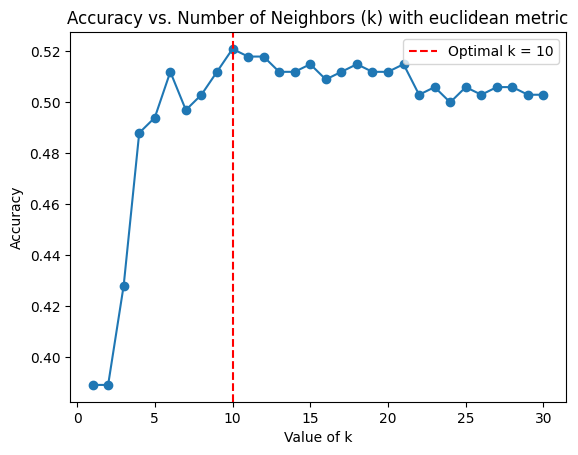

Optimal k value: 10


In [10]:
k_opt = find_k_optimal(X_train, X_test, y_train, y_test)
print("Optimal k value:", k_opt)